In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/metrics_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/per_class_metrics_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/classification_report_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/y_pred_seed_2024.npy
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/all_metrics_seed_100.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/y_pred_probs_seed_2024.npy
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/y_test_seed_2024.npy
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/all_metrics_seed_42.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/three_seed_individual_results.csv
/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder/simple_metrics_mean_std.csv
/kaggle/input/datasets/shehmalhaider/exiting-experime

In [7]:
import os

base_kaggle_path = "/kaggle/input/datasets/shehmalhaider/exiting-experiments"

# Dekhein ke andar direct files hain ya koi sub-folder hai
print("Folders and files inside dataset:")
for root, dirs, files in os.walk(base_kaggle_path):
    npy_files = [f for f in files if f.endswith('.npy')]
    if npy_files:
        print(f"\nTarget Directory found: {root}")
        print("Sample files:", npy_files[:5])

Folders and files inside dataset:

Target Directory found: /kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder
Sample files: ['y_pred_seed_2024.npy', 'y_pred_probs_seed_2024.npy', 'y_test_seed_2024.npy', 'y_test_seed_42.npy', 'y_pred_probs_seed_100.npy']


In [9]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Agar zip ke andar '5seed_fog_threat_blockchain' wala folder tha, 
# to path ko adjust kar lein, warna direct base path use karein:
data_dir = None
base_kaggle_path = "/kaggle/input/datasets/shehmalhaider/exiting-experiments"

# Auto-detect exact folder containing the npy files
for root, dirs, files in os.walk(base_kaggle_path):
    if "y_test_seed_42.npy" in files:
        data_dir = root
        break

if data_dir is None:
    print("Files nahi milin! Path dobara check karein.")
else:
    print(f"Reading files from: {data_dir}")
    
    seeds = [42, 100, 2024]
    n_bootstraps = 1000
    rng = np.random.RandomState(42)
    results_summary = []

    for seed in seeds:
        y_test_file = os.path.join(data_dir, f"y_test_seed_{seed}.npy")
        y_pred_file = os.path.join(data_dir, f"y_pred_seed_{seed}.npy")
        
        y_true = np.load(y_test_file)
        y_pred = np.load(y_pred_file)
        
        n_samples = len(y_true)
        acc_list, prec_list, rec_list, f1_list = [], [], [], []
        
        print(f"Calculating for seed {seed}...")
        for _ in range(n_bootstraps):
            idx = rng.randint(0, n_samples, n_samples)
            acc_list.append(accuracy_score(y_true[idx], y_pred[idx]))
            prec_list.append(precision_score(y_true[idx], y_pred[idx], average='weighted', zero_division=0))
            rec_list.append(recall_score(y_true[idx], y_pred[idx], average='weighted', zero_division=0))
            f1_list.append(f1_score(y_true[idx], y_pred[idx], average='weighted', zero_division=0))
        
        results_summary.append({
            "Seed": seed,
            "Accuracy (95% CI)": f"[{np.percentile(acc_list, 2.5):.4f}, {np.percentile(acc_list, 97.5):.4f}]",
            "Precision (95% CI)": f"[{np.percentile(prec_list, 2.5):.4f}, {np.percentile(prec_list, 97.5):.4f}]",
            "Recall (95% CI)": f"[{np.percentile(rec_list, 2.5):.4f}, {np.percentile(rec_list, 97.5):.4f}]",
            "F1-Score (95% CI)": f"[{np.percentile(f1_list, 2.5):.4f}, {np.percentile(f1_list, 97.5):.4f}]"
        })

    df_ci = pd.DataFrame(results_summary)
    df_ci.to_csv("bootstrap_ci_results.csv", index=False)
    display(df_ci)

Reading files from: /kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder
Calculating for seed 42...
Calculating for seed 100...
Calculating for seed 2024...


,Seed,Accuracy (95% CI),Precision (95% CI),Recall (95% CI),F1-Score (95% CI)
0,42,"[0.8948, 0.8961]","[0.9157, 0.9167]","[0.8948, 0.8961]","[0.8969, 0.8981]"
1,100,"[0.9002, 0.9015]","[0.9238, 0.9248]","[0.9002, 0.9015]","[0.9023, 0.9035]"
2,2024,"[0.8977, 0.8989]","[0.9227, 0.9237]","[0.8977, 0.8989]","[0.9013, 0.9025]"


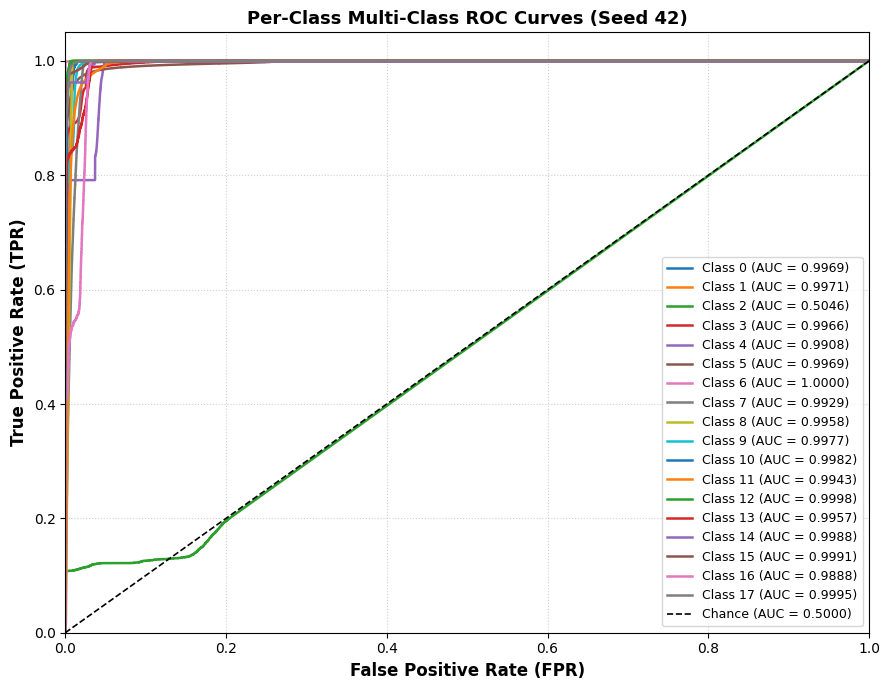

Per-class ROC plot saved as per_class_roc_curves.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Seed 42 ke probabilities aur true labels load karein
y_true = np.load(os.path.join(data_dir, "y_test_seed_42.npy"))
y_probs = np.load(os.path.join(data_dir, "y_pred_probs_seed_42.npy"))

# Classes identify karein
classes = np.unique(y_true)
n_classes = len(classes)

# Labels binarize karein for multi-class ROC
y_true_bin = label_binarize(y_true, classes=classes)
if n_classes == 2:
    y_true_bin = np.column_stack([1 - y_true_bin, y_true_bin])

fpr = dict()
tpr = dict()
roc_auc = dict()

# Har class ke liye ROC aur AUC calculate karein
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
plt.figure(figsize=(9, 7))

# Per-class curves
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=1.8, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.4f})')

# Diagonal line (random chance)
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Chance (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('Per-Class Multi-Class ROC Curves (Seed 42)', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Publication quality save
plt.savefig("per_class_roc_curves.png", dpi=300)
plt.show()
print("Per-class ROC plot saved as per_class_roc_curves.png")

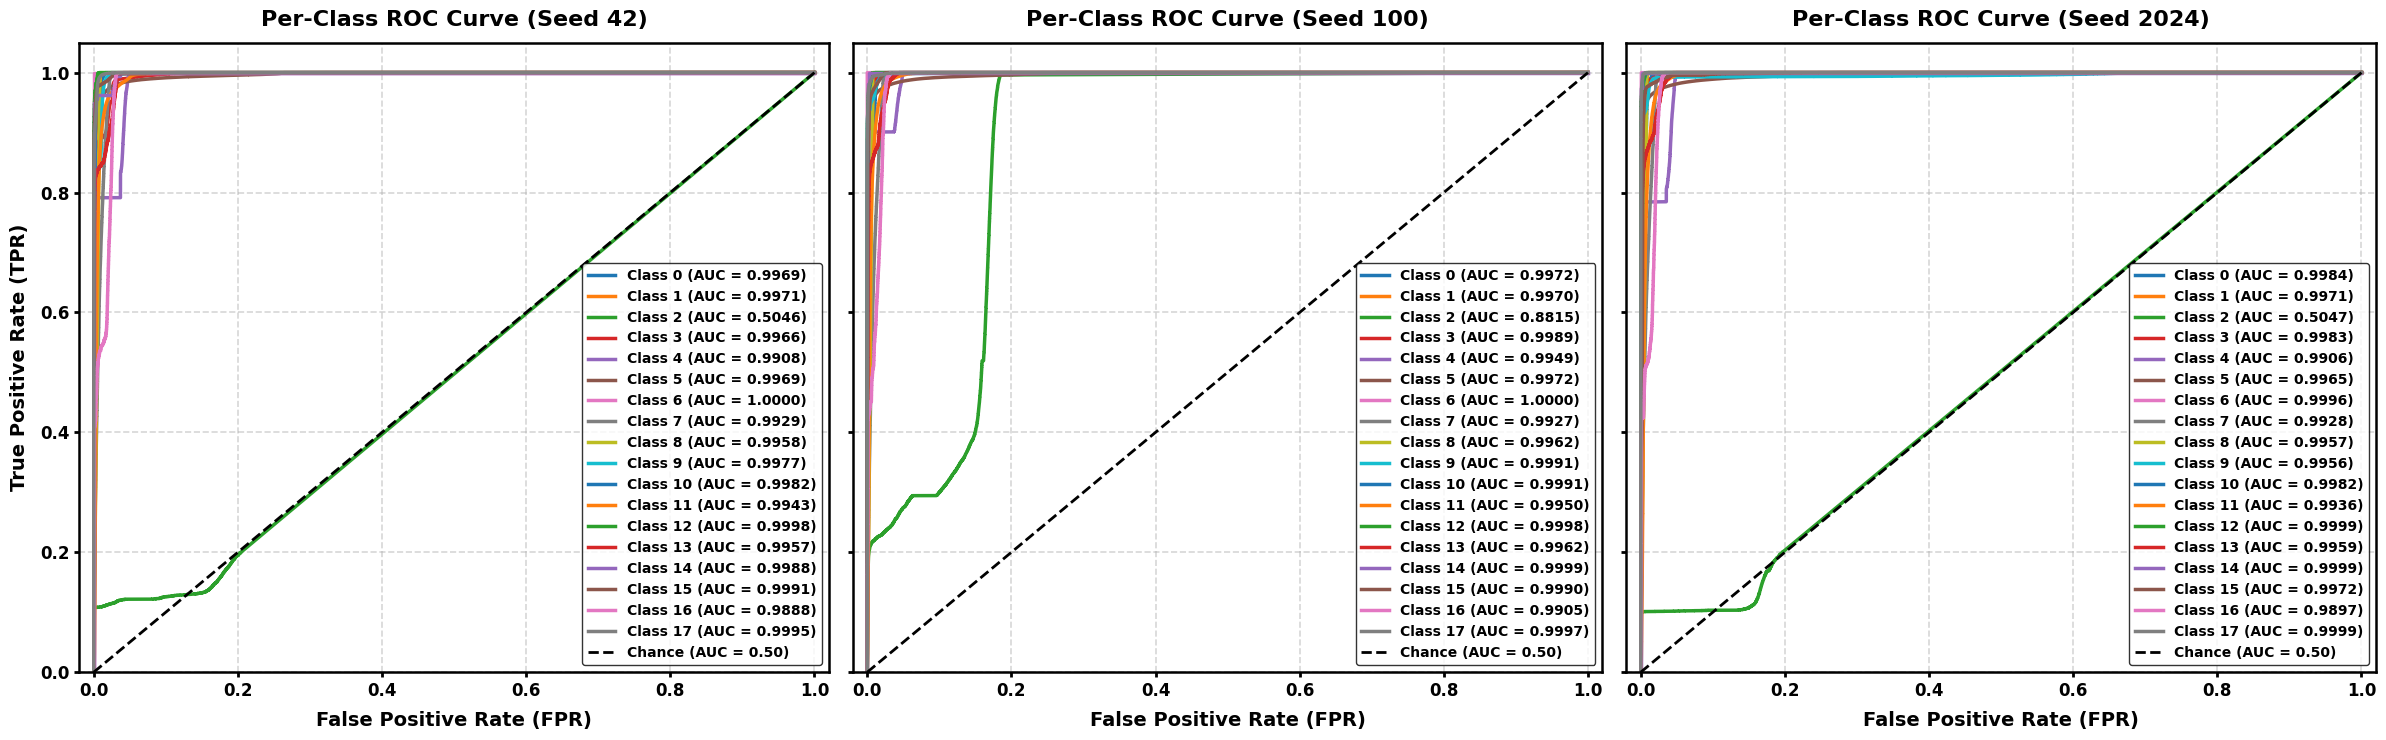

Ultra HD 600 DPI Graph successfully save ho gaya: per_class_roc_3_seeds_bold_600dpi.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Dataset path
data_dir = "/kaggle/input/datasets/shehmalhaider/exiting-experiments/zip folder"
seeds = [42, 100, 2024]

# Figure styling: Globally sabhi text aur ticks ko bold aur prominent banana
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

fig, axes = plt.subplots(1, 3, figsize=(24, 7.5), sharey=True)

for idx, seed in enumerate(seeds):
    ax = axes[idx]
    
    # 1. Files load karein
    y_true = np.load(os.path.join(data_dir, f"y_test_seed_{seed}.npy"))
    y_probs = np.load(os.path.join(data_dir, f"y_pred_probs_seed_{seed}.npy"))
    
    # 2. Classes identify aur binarize karein
    classes = np.unique(y_true)
    n_classes = len(classes)
    y_true_bin = label_binarize(y_true, classes=classes)
    
    if n_classes == 2:
        y_true_bin = np.column_stack([1 - y_true_bin, y_true_bin])
        
    # 3. Har class ka ROC curve plot karein
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(
            fpr, tpr, 
            lw=2.5, 
            label=f'Class {classes[i]} (AUC = {roc_auc:.4f})'
        )
        
    # Diagonal Chance baseline
    ax.plot([0, 1], [0, 1], 'k--', lw=2.0, label='Chance (AUC = 0.50)')
    
    # Limits and ticks
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([0.0, 1.05])
    
    # Bold Tick Labels
    ax.tick_params(axis='both', which='major', labelsize=12, width=2)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
    
    # Bold Labels and Titles
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=14, fontweight='bold', labelpad=8)
    if idx == 0:
        ax.set_ylabel('True Positive Rate (TPR)', fontsize=14, fontweight='bold', labelpad=8)
    
    ax.set_title(f'Per-Class ROC Curve (Seed {seed})', fontsize=16, fontweight='bold', pad=12)
    
    # Bold Legend
    legend = ax.legend(loc="lower right", fontsize=10, frameon=True, edgecolor='black')
    for text in legend.get_texts():
        text.set_fontweight('bold')
        
    # Bold borders (spines) and grid
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=1.2)

plt.tight_layout()

# 600 DPI for high publication quality
output_path = "per_class_roc_3_seeds_bold_600dpi.png"
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

print(f"Ultra HD 600 DPI Graph successfully save ho gaya: {output_path}")